In [ ]:
import glob
import os
import subprocess
import sys
import time
import types

REPO = "/content/ai4animationpy"


def sh(cmd):
    subprocess.run(cmd, shell=True, check=False,
                   stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)


if not os.path.isdir(REPO):
    print("[setup] cloning AI4AnimationPy ...")
    sh(f"git clone --depth 1 https://github.com/facebookresearch/ai4animationpy.git {REPO}")

print("[setup] installing dependencies ...")
sh("apt-get -qq install -y libportaudio2")
sh(f"{sys.executable} -m pip install -q einops pygltflib soundfile sounddevice")

for _name in ("sounddevice", "soundfile", "torchaudio"):
    try:
        __import__(_name)
    except Exception as _e:
        print(f"[setup] '{_name}' unavailable ({type(_e).__name__}) -> stubbing it out")
        sys.modules[_name] = types.ModuleType(_name)

sys.path.insert(0, REPO)

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import display, Image
from matplotlib import animation

from ai4animation import (
    AI4Animation, CosineAnnealingOptimizer, DataSampler, Dataset, FeedTensor,
    MirrorModule, Motion, MotionModule, MultiLayerPerceptron, Plotting, ReadTensor,
    RootModule, Rotation, Tensor, TimeSeries, Transform, Utility, Vector3,
)

Utility.GetNumWorkers = lambda: max(1, (os.cpu_count() or 2) // 2)

print(f"[setup] torch {torch.__version__} | numpy {np.__version__} | "
      f"device {'cuda' if torch.cuda.is_available() else 'cpu'} | workers {Utility.GetNumWorkers()}")

ASSETS = os.path.join(REPO, "Demos/_ASSETS_/Geno")
sys.path.append(ASSETS)
import Definitions

BONES = Definitions.FULL_BODY_NAMES
NUM_BONES = len(BONES)

FRAMERATE = 30
BATCH_SIZE = 32
EPOCH_COUNT = 25
COVERAGE = 0.05
TIME_BUDGET_MIN = 8.0
HIDDEN_DIM = 512

FUTURE_WINDOW = 0.5
FUTURE_SAMPLES = 11
FUTURE_DT = FUTURE_WINDOW / (FUTURE_SAMPLES - 1)
ROLLOUT_STRIDE = 1

INPUT_DIM = 12 * NUM_BONES
OUTPUT_DIM = FUTURE_SAMPLES * 4 + FUTURE_SAMPLES * NUM_BONES * 9
print(f"[config] {NUM_BONES} joints | input {INPUT_DIM} | output {OUTPUT_DIM}")

In [ ]:
TRAIN_DIR, VAL_DIR = "/content/data/train", "/content/data/val"


def SplitClips(source_dir, train_dir, val_dir, val_ratio=0.15):
    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(val_dir, exist_ok=True)
    for path in sorted(glob.glob(os.path.join(source_dir, "*.npz"))):
        data = np.load(path, allow_pickle=True)
        frames = data["positions"].shape[0]
        cut = int(frames * (1.0 - val_ratio))
        name = os.path.splitext(os.path.basename(path))[0]
        for out_dir, sl, tag in ((train_dir, slice(0, cut), "train"),
                                 (val_dir, slice(cut, frames), "val")):
            np.savez_compressed(
                os.path.join(out_dir, f"{name}.npz"),
                name=f"{name}_{tag}",
                framerate=data["framerate"],
                positions=data["positions"][sl],
                quaternions=data["quaternions"][sl],
                bone_names=data["bone_names"],
                parent_names=data["parent_names"],
                parent_indices=data["parent_indices"],
            )
        print(f"  {name}: {cut} train / {frames - cut} val frames")


SplitClips(os.path.join(ASSETS, "Motions"), TRAIN_DIR, VAL_DIR)


def MODULES():
    """Analysis modules attached to every clip when it is loaded.

    RootModule   - synthesises a stable ground-projected character root (the space every
                   feature is expressed in; this is what makes features translation- and
                   heading-invariant).
    MotionModule - per-joint transform/velocity sampling with optional smoothing + noise.
    MirrorModule - left/right mirroring, used as free 2x data augmentation.
    """
    return [
        lambda x: RootModule(
            x,
            Definitions.HipName,
            Definitions.LeftHipName,
            Definitions.RightHipName,
            Definitions.LeftShoulderName,
            Definitions.RightShoulderName,
            Definitions.NeckName,
        ),
        lambda x: MotionModule(x),
        lambda x: MirrorModule(
            x,
            Vector3.Axis.ZPositive,
            correction=Vector3.Create(180, 0, 180),
            map=MirrorModule.Map.All,
        ),
    ]

In [ ]:
class Program:
    def Start(self):
        Utility.SetSeed(23456)

        self.Dataset = Dataset(TRAIN_DIR, MODULES())
        self.Sampler = DataSampler(
            self.Dataset,
            framerate=FRAMERATE,
            batch_size=BATCH_SIZE,
            function=self.GetTrainingFeatures,
            start_padding=0.5,
            end_padding=FUTURE_WINDOW + 0.1,
            coverage=COVERAGE,
        )

        self.Network = Tensor.ToDevice(
            MultiLayerPerceptron.Model(
                input_dim=INPUT_DIM, output_dim=OUTPUT_DIM, hidden_dim=HIDDEN_DIM
            )
        )
        self.Optimizer = CosineAnnealingOptimizer(
            self.Network.parameters(), self.Sampler.BatchSize, self.Sampler.BatchCount
        )
        self.LossHistory = Plotting.LossHistory(
            "Loss History", self.Sampler.BatchCount, drawInterval=None
        )

        self.FutureSeries = TimeSeries(start=0.0, end=FUTURE_WINDOW, samples=FUTURE_SAMPLES)
        self.Deadline = time.time() + TIME_BUDGET_MIN * 60.0
        self.Finished = False
        self.Trainer = self.Training()

    def Update(self):
        try:
            next(self.Trainer)
        except StopIteration:
            self.Finished = True

    def Training(self):
        for epoch in range(1, EPOCH_COUNT + 1):
            for xBatch, yBatch in self.Sampler.SampleBatchesWithinMotions(epoch, EPOCH_COUNT):
                _, loss = self.Network.learn(xBatch, yBatch, epoch == 1)
                self.Optimizer.Update(loss)
                self.LossHistory.Add(loss)
                yield
            self.LossHistory.Print()
            if time.time() > self.Deadline:
                print(f"[train] time budget reached after {epoch} epochs — stopping early.")
                return

    def GetTrainingFeatures(self, batch):
        """Called on worker threads with (motion, timestamps[BATCH_SIZE])."""
        motion, timestamps = batch
        mirrored = Tensor.RandomBool()
        root_module = motion.GetModule(RootModule)
        motion_module = motion.GetModule(MotionModule)

        inputs = FeedTensor("X", (len(timestamps), INPUT_DIM))
        outputs = FeedTensor("Y", (len(timestamps), OUTPUT_DIM))

        window = Tensor.RandomUniform(min=0.0, max=1.0)
        smoothing = TimeSeries(-window / 2.0, window / 2.0, 10)

        rootInv = Tensor.Inverse(
            root_module.GetTransforms(timestamps, mirrored=mirrored, smoothing=smoothing)
        )

        transforms = Transform.TransformationFrom(
            motion.GetBoneTransformations(timestamps, BONES, mirrored=mirrored),
            rootInv.reshape(-1, 1, 4, 4),
        )
        velocities = Vector3.DirectionFrom(
            motion.GetBoneVelocities(timestamps, BONES, mirrored=mirrored),
            rootInv.reshape(-1, 1, 4, 4),
        )
        inputs.Feed(Transform.GetPosition(transforms))
        inputs.Feed(Transform.GetAxisZ(transforms))
        inputs.Feed(Transform.GetAxisY(transforms))
        inputs.Feed(velocities)

        futureTimestamps = self.FutureSeries.SimulateTimestamps(timestamps)
        futureRoot = Transform.TransformationFrom(
            root_module.GetTransforms(futureTimestamps, mirrored),
            rootInv.reshape(-1, 1, 4, 4),
        )
        futureMotion = Transform.TransformationFrom(
            motion_module.GetTransforms(futureTimestamps, mirrored, BONES),
            rootInv.reshape(-1, 1, 1, 4, 4),
        )
        outputs.FeedVector3(Transform.GetPosition(futureRoot), x=True, y=False, z=True)
        outputs.FeedVector3(Transform.GetAxisZ(futureRoot), x=True, y=False, z=True)
        outputs.Feed(Transform.GetPosition(futureMotion))
        outputs.Feed(Rotation.GetAxisZ(futureMotion))
        outputs.Feed(Rotation.GetAxisY(futureMotion))

        return inputs.GetTensor(), outputs.GetTensor()

In [ ]:
program = Program()
AI4Animation(program, mode=AI4Animation.Mode.MANUAL)

print("\n[train] starting — one engine tick == one gradient step\n")
t0 = time.time()
while not program.Finished:
    AI4Animation.Update(1.0 / 60.0)
print(f"[train] done in {(time.time() - t0) / 60.0:.1f} min")

network = program.Network
network.eval()

fig, ax = plt.subplots(figsize=(9, 3.5))
for label, (values, cumulative) in program.LossHistory.Functions.items():
    ax.plot(values, lw=0.5, alpha=0.4, label=label)
    ax.plot(cumulative, lw=2.0, label=f"{label} (running mean)")
ax.set_yscale("log")
ax.set_xlabel("gradient step")
ax.set_ylabel("MSE (normalised space)")
ax.legend()
ax.set_title("Training")
plt.tight_layout()
plt.show()

val_motion = Motion.LoadFromNPZ(sorted(glob.glob(os.path.join(VAL_DIR, "*.npz")))[-1])
val_motion.AddModules(MODULES())
print(f"[eval] validation clip '{val_motion.Name}' — "
      f"{val_motion.NumFrames} frames, {val_motion.TotalTime:.1f}s @ {val_motion.Framerate:.0f} fps")

PARENTS = []
for name in BONES:
    parent = val_motion.Hierarchy.ParentNames[val_motion.Hierarchy.NameToIndex[name]]
    PARENTS.append(BONES.index(parent) if parent in BONES else -1)


def BuildInput(bones, velocities, root):
    """World-space state -> network input vector (no batch dimension)."""
    rootInv = Tensor.Inverse(root)
    local = Transform.TransformationFrom(bones, rootInv)
    localVel = Vector3.DirectionFrom(velocities, rootInv)
    x = FeedTensor("X", INPUT_DIM)
    x.Feed(Transform.GetPosition(local))
    x.Feed(Transform.GetAxisZ(local))
    x.Feed(Transform.GetAxisY(local))
    x.Feed(localVel)
    return x.GetTensor()


def Predict(bones, velocities, root):
    """-> (future root [S,4,4], future pose [S,J,4,4]) in world space."""
    with torch.no_grad():
        y = Tensor.ToNumPy(network(BuildInput(bones, velocities, root)))
    out = ReadTensor("Y", y)
    futureRoot = Transform.TR(
        out.ReadVector3(FUTURE_SAMPLES, x=True, y=False, z=True),
        Rotation.Look(
            out.ReadVector3(FUTURE_SAMPLES, x=True, y=False, z=True),
            Vector3.UnitY(FUTURE_SAMPLES),
        ),
    )
    futureMotion = Transform.TR(
        out.ReadVector3((FUTURE_SAMPLES, NUM_BONES)),
        out.ReadRotation3D((FUTURE_SAMPLES, NUM_BONES)),
    )
    return (Transform.TransformationFrom(futureRoot, root),
            Transform.TransformationFrom(futureMotion, root))


def GroundTruthState(motion, t, mirrored=False):
    ts = np.array([t], dtype=np.float32)
    return (motion.GetBoneTransformations(ts, BONES, mirrored)[0],
            motion.GetBoneVelocities(ts, BONES, mirrored)[0],
            motion.GetModule(RootModule).GetTransforms(ts, mirrored)[0])

In [ ]:
def Evaluate(motion, trials=64):
    rng = np.random.default_rng(0)
    horizon = np.linspace(0.0, FUTURE_WINDOW, FUTURE_SAMPLES)
    times = rng.uniform(0.6, max(0.7, motion.TotalTime - FUTURE_WINDOW - 0.1), trials)
    model_err = np.zeros(FUTURE_SAMPLES)
    frozen_err = np.zeros(FUTURE_SAMPLES)
    for t in times:
        bones, velocities, root = GroundTruthState(motion, float(t))
        _, predicted = Predict(bones, velocities, root)
        truth = motion.GetBoneTransformations((t + horizon).astype(np.float32), BONES)
        p_pred = Transform.GetPosition(predicted)
        p_true = Transform.GetPosition(truth)
        p_hold = Transform.GetPosition(bones)[None]
        model_err += np.linalg.norm(p_pred - p_true, axis=-1).mean(axis=-1)
        frozen_err += np.linalg.norm(p_hold - p_true, axis=-1).mean(axis=-1)
    return 100.0 * model_err / len(times), 100.0 * frozen_err / len(times)


model_err, frozen_err = Evaluate(val_motion)
print("\n horizon |  network  |  frozen-pose baseline")
for i in range(0, FUTURE_SAMPLES, 2):
    print(f"  {i * FUTURE_DT:4.2f}s  | {model_err[i]:7.2f}cm | {frozen_err[i]:7.2f}cm")


def Rollout(motion, start_time, seconds):
    bones, velocities, root = GroundTruthState(motion, start_time)
    steps = int(seconds / (ROLLOUT_STRIDE * FUTURE_DT))
    trajectory = [Transform.GetPosition(bones)]
    for _ in range(steps):
        futureRoot, futureMotion = Predict(bones, velocities, root)
        nextRoot = futureRoot[ROLLOUT_STRIDE]
        nextBones = futureMotion[ROLLOUT_STRIDE]
        velocities = (Transform.GetPosition(nextBones) - Transform.GetPosition(bones)) / (
            ROLLOUT_STRIDE * FUTURE_DT
        )
        bones, root = nextBones, nextRoot
        trajectory.append(Transform.GetPosition(bones))
    return np.stack(trajectory)


START_TIME, DURATION = 1.0, 3.0
rollout = Rollout(val_motion, START_TIME, DURATION)
reference = Transform.GetPosition(
    val_motion.GetBoneTransformations(
        np.arange(START_TIME, START_TIME + DURATION + 1e-4,
                  ROLLOUT_STRIDE * FUTURE_DT).astype(np.float32),
        BONES,
    )
)
frames = min(len(rollout), len(reference))

[setup] cloning AI4AnimationPy ...
[setup] installing dependencies ...
[setup] torch 2.11.0+cpu | numpy 2.0.2 | device cpu | workers 1
[config] 23 joints | input 276 | output 2321
  aiming1_subject1: 12211 train / 2156 val frames
  ground1_subject1: 8060 train / 1423 val frames
  run1_subject2: 12128 train / 2141 val frames
  sprint1_subject4: 13928 train / 2459 val frames
  walk3_subject3: 12575 train / 2220 val frames
Auto-detected num workers=1 (2 CPU cores)
Generating data sampler for 5 files at 30 FPS


Loading motions: 100%|██████████| 5/5 [00:00<00:00,  5.55file/s]


Per-Epoch Coverage: 0.05
Training Samples: 1440 / 29287
Training Batches: 45 @ 32
Motion Duration: 0h 0m 48s

[train] starting — one engine tick == one gradient step



Epoch 1/25: 100%|████████████████████████████████████████████████████████████████████████████████████████| 45/45 [00:03<00:00, 14.59batch/s]


MSE Loss: 0.83452 


...

MSE Loss: 0.27642 


Epoch 24/25: 100%|███████████████████████████████████████████████████████████████████████████████████████| 45/45 [00:01<00:00, 40.84batch/s]


MSE Loss: 0.28534 


Epoch 25/25: 100%|███████████████████████████████████████████████████████████████████████████████████████| 45/45 [00:01<00:00, 40.78batch/s]


MSE Loss: 0.26154 
[train] done in 0.5 min


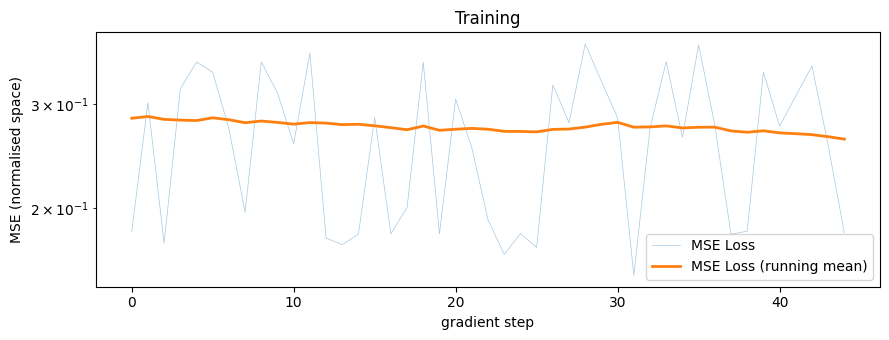

[eval] validation clip 'walk3_subject3_val' — 2220 frames, 37.0s @ 60 fps

 horizon |  network  |  frozen-pose baseline
  0.00s  |    6.71cm |    0.00cm
  0.10s  |    6.79cm |    2.20cm
  0.20s  |    7.62cm |    4.23cm
  0.30s  |    9.03cm |    6.12cm
  0.40s  |   10.92cm |    7.98cm
  0.50s  |   12.98cm |    9.84cm


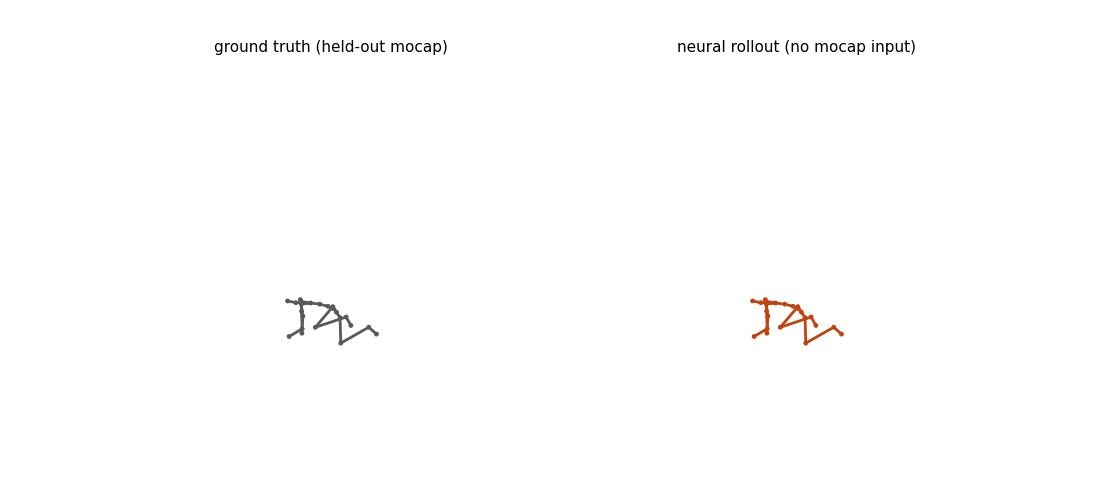

[save] /content/Network.pt written; ONNX export skipped (Module onnx is not installed!)


/tmp/ipykernel_5036/347008515.py:466: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(
/content/ai4animationpy/ai4animation/AI/Library/Statistics.py:59: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if tensor.shape[-1] != self.Dim:
/content/ai4animationpy/ai4animation/AI/Library/Statistics.py:75: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Py

In [1]:
def DrawSkeleton(ax, joints, color, lw=2.0, alpha=1.0):
    for i, p in enumerate(PARENTS):
        if p >= 0:
            a, b = joints[i], joints[p]
            ax.plot([a[0], b[0]], [a[2], b[2]], [a[1], b[1]],
                    c=color, lw=lw, alpha=alpha, solid_capstyle="round")
    ax.scatter(joints[:, 0], joints[:, 2], joints[:, 1], c=color, s=6, alpha=alpha)


def Animate(sequences, labels, colors, path="/content/rollout.gif", fps=20):
    fig = plt.figure(figsize=(5.5 * len(sequences), 5.0))
    axes = [fig.add_subplot(1, len(sequences), i + 1, projection="3d")
            for i in range(len(sequences))]
    span = 1.4

    def draw(f):
        for ax, seq, label, color in zip(axes, sequences, labels, colors):
            ax.cla()
            joints = seq[f]
            centre = joints[0]
            ax.set_xlim(centre[0] - span, centre[0] + span)
            ax.set_ylim(centre[2] - span, centre[2] + span)
            ax.set_zlim(0.0, 2.0 * span)
            ax.set_box_aspect((1, 1, 0.9))
            ax.set_axis_off()
            ax.set_title(label, fontsize=11)
            ax.plot(seq[:f + 1, 0, 0], seq[:f + 1, 0, 2], np.zeros(f + 1), c="0.75", lw=1.0)
            DrawSkeleton(ax, joints, color)

    anim = animation.FuncAnimation(fig, draw, frames=frames, interval=1000 // fps)
    anim.save(path, writer=animation.PillowWriter(fps=fps))
    plt.close(fig)
    return path


gif = Animate(
    [reference[:frames], rollout[:frames]],
    ["ground truth (held-out mocap)", "neural rollout (no mocap input)"],
    ["0.35", "#c1440e"],
)
display(Image(filename=gif))

Utility.SaveModel(network, "/content/Network.pt")
try:
    torch.onnx.export(
        network, Tensor.ToDevice(torch.zeros(1, INPUT_DIM)), "/content/Network.onnx",
        input_names=["X"], output_names=["Y"], dynamo=False,
    )
    print("[save] /content/Network.pt and /content/Network.onnx")
except Exception as e:
    print(f"[save] /content/Network.pt written; ONNX export skipped ({e})")